# 6. COMPAS: both sides were right

The recidivism case, on the real data ProPublica released.

In 2016 ProPublica reported that COMPAS was biased against Black defendants.
Northpointe replied that the score was equally accurate for both groups. Both
claims are true. They cannot both be fixed.

This notebook reproduces both, then asks whether it is solvable.

- Chouldechova (2017), `papers/chouldechova-2017-fair-prediction.pdf`, written
  directly about this case
- Kleinberg, Mullainathan & Raghavan (2016), `papers/kleinberg-2016-inherent-tradeoffs.pdf`
- Data: <https://github.com/propublica/compas-analysis>, `../data/`

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('../data/compas-scores-two-years.csv')

# ProPublica's own filtering
df = df[(df.days_b_screening_arrest.abs() <= 30) & (df.is_recid != -1) &
        (df.c_charge_degree != 'O') & (df.score_text != 'N/A')]
df = df[df.race.isin(['African-American', 'Caucasian'])].copy()
df['high_risk'] = df.decile_score >= 5

black = df.race == 'African-American'
white = df.race == 'Caucasian'
print(f'{len(df)} defendants: {black.sum()} Black, {white.sum()} white')

5278 defendants: 3175 Black, 2103 white


## 1. The base rates genuinely differ

This is the fact that makes everything downstream unavoidable. It is also the
fact that is hardest to interpret, and section 5 comes back to it.

In [2]:
for name, mask in (('African-American', black), ('Caucasian', white)):
    print(f'  {name:<18} two-year recidivism = {df[mask].two_year_recid.mean():.1%}')

  African-American   two-year recidivism = 52.3%
  Caucasian          two-year recidivism = 39.1%


## 2. Northpointe's defence: the score is calibrated

A decile of 7 should mean the same probability of reoffending regardless of race.
If it does, the score is not lying to anyone.

In [3]:
print(f'  {"decile":<8}{"Black":>10}{"n":>6}{"white":>10}{"n":>6}{"gap":>8}{"SE":>7}')
for d in range(1, 11):
    s = df[df.decile_score == d]
    bg = s[s.race == 'African-American'].two_year_recid
    wg = s[s.race == 'Caucasian'].two_year_recid
    gap = bg.mean() - wg.mean()
    se = np.sqrt(bg.mean() * (1 - bg.mean()) / len(bg)
                 + wg.mean() * (1 - wg.mean()) / len(wg))
    print(f'  {d:<8}{bg.mean():>10.0%}{len(bg):>6}{wg.mean():>10.0%}{len(wg):>6}'
          f'{gap:>+8.0%}{se:>7.2f}')

  decile       Black     n     white     n     gap     SE
  1              23%   365       21%   605     +2%   0.03
  2              30%   346       31%   321     -1%   0.04
  3              42%   298       34%   238     +7%   0.04
  4              47%   337       40%   243     +7%   0.04
  5              49%   323       46%   200     +3%   0.04
  6              59%   318       58%   160     +1%   0.05
  7              61%   343       60%   113     +1%   0.05
  8              71%   301       75%    96     -4%   0.05
  9              72%   317       71%    77     +1%   0.06
  10             84%   227       70%    50    +14%   0.07


Read the group sizes before reading the gaps. The top decile has far fewer white
defendants than the bottom ones, so its gap carries a standard error around 0.07.
The apparent break at decile 10 is roughly two standard errors: suggestive, not
established. An earlier version of this notebook stated it as a finding, which
was over-reading a small cell.

What is solid is the broad picture: through most of the scale a decile means
about the same thing for both groups, which is what Northpointe claimed.


## 3. ProPublica's finding: the errors are not shared equally

A false positive is a defendant labelled high risk who did **not** reoffend.

In [4]:
print(f'  {"":<18}{"FPR":>8}{"FNR":>8}')
for name, mask in (('African-American', black), ('Caucasian', white)):
    g = df[mask]
    fpr = g[g.two_year_recid == 0].high_risk.mean()
    fnr = 1 - g[g.two_year_recid == 1].high_risk.mean()
    print(f'  {name:<18}{fpr:>8.1%}{fnr:>8.1%}')

                         FPR     FNR
  African-American     42.3%   28.5%
  Caucasian            22.0%   49.6%


Nearly twice the false positive rate, and roughly half the false negative rate.
The errors do not cancel; they point in opposite directions for the two groups.

Both parties were reading the same file. Neither was misrepresenting it.

## 4. Can it be fixed?

Try it. Equalise the false positive rate by choosing a different threshold for
each group, then look at what that costs.

In [5]:
target_fpr = 0.30

def threshold_for_fpr(mask, target):
    g = df[mask]
    negatives = g[g.two_year_recid == 0].decile_score
    for t in range(1, 11):
        if (negatives >= t).mean() <= target:
            return t
    return 11


t_black = threshold_for_fpr(black, target_fpr)
t_white = threshold_for_fpr(white, target_fpr)
df['equalised'] = np.where(black, df.decile_score >= t_black, df.decile_score >= t_white)

print(f'thresholds chosen: Black >= {t_black},  white >= {t_white}\n')
print(f'  {"":<18}{"FPR":>8}{"FNR":>8}{"PPV":>8}{"flagged":>10}')
for name, mask in (('African-American', black), ('Caucasian', white)):
    g = df[mask]
    fpr = g[g.two_year_recid == 0].equalised.mean()
    fnr = 1 - g[g.two_year_recid == 1].equalised.mean()
    ppv = g[g.equalised].two_year_recid.mean()
    print(f'  {name:<18}{fpr:>8.1%}{fnr:>8.1%}{ppv:>8.1%}{g.equalised.mean():>10.1%}')

thresholds chosen: Black >= 7,  white >= 5

                         FPR     FNR     PPV   flagged
  African-American     22.8%   49.2%   71.0%     37.4%
  Caucasian            22.0%   49.6%   59.5%     33.1%


The false positive rates now match. Two things were spent to buy that.

The **positive predictive value** now differs between groups, so "flagged as high
risk" means something different depending on race. And the **thresholds
differ**, so two defendants with the same decile score get different decisions
because of their race. In a bail hearing that is not a technical detail.

**This is Chouldechova's theorem, arrived at by hand.** The theorem states that
with unequal base rates you cannot have calibration (equivalently equal PPV) and
equal false positive *and* false negative rates at once, unless prediction is
perfect. Equalising FPR by group is exactly what opened the PPV gap above.

The threshold point - that two defendants with the same score now get different
decisions - is a separate objection, legal rather than mathematical. It is not
part of the theorem, and the earlier version of this notebook wrongly listed it
as the third leg.

## 5. The part that is not a maths problem

`two_year_recid` is **re-arrest**, not reoffending. The two differ by however
much policing intensity differs between neighbourhoods, and nobody in this
dataset knows by how much. So some unknown share of the 52.3 vs 39.1 gap in
section 1 is enforcement rather than conduct.

That matters more than any of the arithmetic above, because every fairness
criterion here is defined against that label. If the label is a measurement of
policing, then a perfectly calibrated model is a perfectly calibrated model of
policing, and calling its output "risk of reoffending" is a claim nobody has
established.

Second, the prediction is not passive. Detention costs employment and housing,
which raises the probability of the outcome being predicted. A model that
influences the thing it forecasts cannot be validated the way a weather forecast
can.

## Is it solvable?

Not as posed. What is available:

- **A better label.** Convictions rather than arrests is better and still not
  clean. This is the largest available improvement and it is a data collection
  problem, not a modelling one.
- **An explicit choice of which error to equalise,** argued in public, with the
  reasoning recorded. That is a policy act, and it is Blackstone's question,
  which dates from the 1760s.
- **Restricting features to individual conduct** rather than circumstance, at a
  known cost in accuracy.
- **Deciding the decision should not be automated.** A legitimate outcome, and
  the one this literature is least willing to state.

What the technical work can do is map the trade-off precisely and refuse to let
anyone pretend it is not there. It cannot choose the point on it.

## The picture


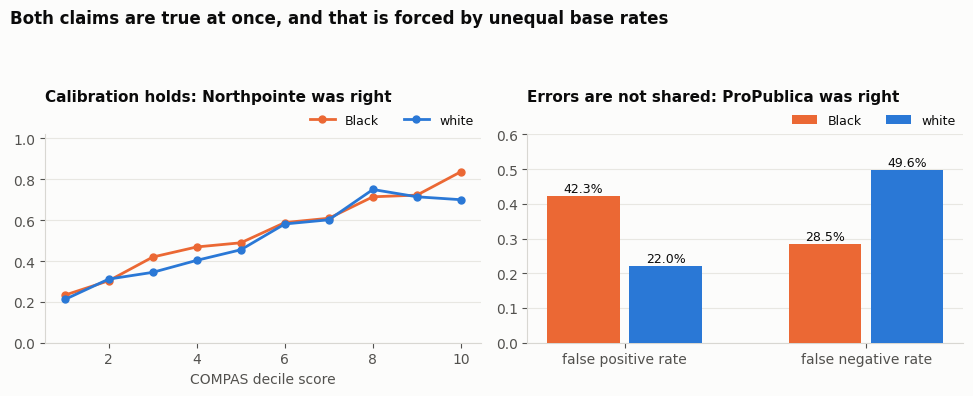

In [6]:
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, SURFACE = '#0b0b0b', '#52514e', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
                     'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
                     'axes.labelcolor': MUTED, 'text.color': INK,
                     'xtick.color': MUTED, 'ytick.color': MUTED})


def tidy(ax, xgrid=True):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color('#d8d7d2')
    ax.grid(axis='x' if xgrid else 'y', color='#e8e7e2', lw=0.8)
    ax.set_axisbelow(True)

fig, axes = plt.subplots(1, 2, figsize=(9.8, 4.0))

deciles = range(1, 11)
for race, colour, lab in (('African-American', ORANGE, 'Black'), ('Caucasian', BLUE, 'white')):
    rates = [df[(df.decile_score == d) & (df.race == race)].two_year_recid.mean()
             for d in deciles]
    axes[0].plot(deciles, rates, color=colour, lw=2, marker='o', ms=5, label=lab, zorder=3)
axes[0].legend(frameon=False, ncol=2, fontsize=9, loc='lower right', bbox_to_anchor=(1.0, 1.0), borderaxespad=0.2)
tidy(axes[0], xgrid=False)
axes[0].set_xlabel('COMPAS decile score')
axes[0].set_title('Calibration holds: Northpointe was right', loc='left', pad=24)
axes[0].set_ylim(0, 1.02)

metrics = {}
for race, mask in (('Black', black), ('white', white)):
    g = df[mask]
    metrics[race] = (g[g.two_year_recid == 0].high_risk.mean(),
                     1 - g[g.two_year_recid == 1].high_risk.mean())
x = np.arange(2)
axes[1].bar(x - 0.17, metrics['Black'], 0.30, label='Black', color=ORANGE, zorder=3)
axes[1].bar(x + 0.17, metrics['white'], 0.30, label='white', color=BLUE, zorder=3)
for xi in x:
    axes[1].text(xi - 0.17, metrics['Black'][xi] + 0.012,
                 f"{metrics['Black'][xi]:.1%}", ha='center', fontsize=9, color=INK)
    axes[1].text(xi + 0.17, metrics['white'][xi] + 0.012,
                 f"{metrics['white'][xi]:.1%}", ha='center', fontsize=9, color=INK)
axes[1].set_xticks(x, ['false positive rate', 'false negative rate'])
axes[1].legend(frameon=False, ncol=2, fontsize=9, loc='lower right', bbox_to_anchor=(1.0, 1.0), borderaxespad=0.2)
tidy(axes[1], xgrid=False)
axes[1].set_ylim(0, 0.60)
axes[1].set_title('Errors are not shared: ProPublica was right', loc='left', pad=24)
fig.suptitle('Both claims are true at once, and that is forced by unequal base rates',
             x=0.012, ha='left', fontsize=12, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig('../figures/06_compas.png', dpi=150, bbox_inches='tight')
plt.show()

## The whole picture: two ROC curves

Every threshold rule anybody can pick is a point on one of these curves. Barocas,
Hardt & Narayanan draw this in their credit-scoring case study, and it is the
clearest single view of the argument: the two groups have *different* curves, so
any rule that fixes one quantity has to move along them separately.

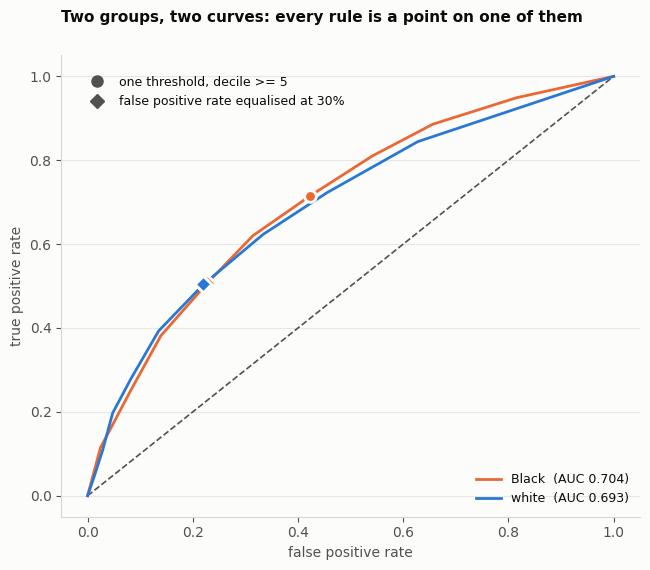

thresholds: Black >= 7, white >= 5   (white barely moves, which is why its two markers sit on top of each other)


In [7]:
from sklearn.metrics import roc_curve, roc_auc_score
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(6.6, 5.8))
for race, colour, lab in (('African-American', ORANGE, 'Black'),
                          ('Caucasian', BLUE, 'white')):
    g = df[df.race == race]
    fpr, tpr, _ = roc_curve(g.two_year_recid, g.decile_score)
    auc = roc_auc_score(g.two_year_recid, g.decile_score)
    ax.plot(fpr, tpr, color=colour, lw=2, zorder=3, label=f'{lab}  (AUC {auc:.3f})')
    for mark, col in (('o', 'high_risk'), ('D', 'equalised')):
        ax.scatter(g[g.two_year_recid == 0][col].mean(),
                   g[g.two_year_recid == 1][col].mean(),
                   s=70, color=colour, edgecolor=SURFACE, lw=2, marker=mark, zorder=5)

ax.plot([0, 1], [0, 1], color=MUTED, lw=1.2, ls='--', zorder=2)
races = ax.legend(frameon=False, fontsize=9, loc='lower right')
ax.add_artist(races)
ax.legend(handles=[Line2D([], [], marker='o', ls='', color=MUTED, ms=8,
                          label='one threshold, decile >= 5'),
                   Line2D([], [], marker='D', ls='', color=MUTED, ms=7,
                          label='false positive rate equalised at 30%')],
          frameon=False, fontsize=9, loc='upper left', bbox_to_anchor=(0.02, 0.98))
tidy(ax, xgrid=False)
ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax.set_title('Two groups, two curves: every rule is a point on one of them',
             loc='left', pad=24)
fig.tight_layout()
plt.savefig('../figures/06_group_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'thresholds: Black >= {t_black}, white >= {t_white}   '
      f'(white barely moves, which is why its two markers sit on top of each other)')


The curves are close but not identical, and the two groups sit at different
points on them. A single decile cut-off puts Black defendants at a much higher
false positive rate; equalising the false positive rate slides both groups to the
same x-coordinate and, because the curves differ, to *different* true positive
rates and different thresholds.

There is no point on this plot where the two groups have the same false positive
rate, the same false negative rate and the same PPV. That is the theorem, drawn.